# Problema 1

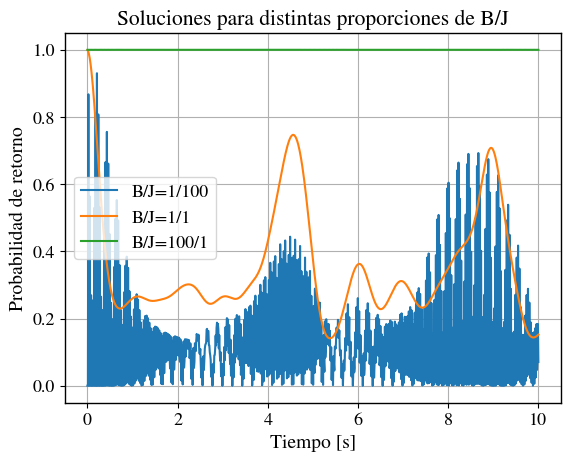

Tiempo de cálculo para N=4: 0.006064 +- 0.001850 segundos
Tiempo de cálculo para N=5: 0.005428 +- 0.004169 segundos
Tiempo de cálculo para N=6: 0.007481 +- 0.004566 segundos
Tiempo de cálculo para N=7: 0.013720 +- 0.002748 segundos
Tiempo de cálculo para N=8: 0.034729 +- 0.005546 segundos
Tiempo de cálculo para N=9: 0.124339 +- 0.009503 segundos
[2.92408297e-06 1.18366054e+00]


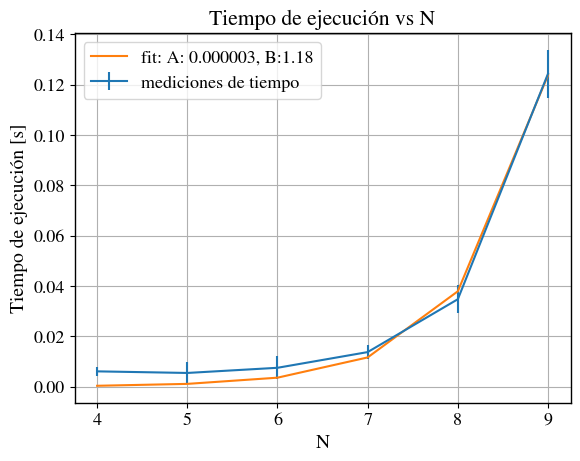

Tiempo estimado para N=20: 55864.31759041977
Tiempo estimado para N=50: 1.4752027351071595e+20
Tiempo estimado para N=100: 7.442412323586799e+45


In [ ]:
import torch
import time
import numpy as np
import scipy as sp
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device=torch.device("cpu")

sx = torch.tensor([[0, 1], [1, 0]], dtype=torch.complex128, device=device)
sy = torch.tensor([[0, -1j],[1j, 0]], dtype=torch.complex128, device=device)
sz = torch.tensor([[1, 0], [0, -1]], dtype=torch.complex128, device=device)
eye = torch.eye(2, dtype=torch.complex128, device=device)   #identidad 2x2



def get_hamiltonian(N, J, B):

    dim = 2**N
    H = torch.zeros((dim, dim), dtype=torch.complex128, device=device)

    # --- Término J (Interacción de pares vecinos) ---
    for i in range(N - 1):
        # Empezamos con la identidad o con sigma_x si i=0
        op_list = []
        for j in range(N):
            if j == i or j == i + 1:
                op_list.append(sx)
            else:
                op_list.append(eye)

        # Combinamos toda la cadena en un solo producto de Kronecker
        term = op_list[0]
        for next_op in op_list[1:]:
            term = torch.kron(term, next_op)
        H += J * term

    # --- Término B (Campo transversal) ---
    for i in range(N):
        op_list = []
        for j in range(N):
            if j == i:
                op_list.append(sz)
            else:
                op_list.append(eye)

        term = op_list[0]
        for next_op in op_list[1:]:
            term = torch.kron(term, next_op)
        H += B * term

    return H

def get_initial_state(N):
    psi_0 = torch.tensor([[0],[1]], device=device) #down
    for i in range(N-1):
        psi_0 = torch.kron(psi_0, torch.tensor([[0],[1]], dtype=torch.complex128, device=device))
    return (psi_0)

def simulate_evolution(N, J, B, dt, steps):
    H = get_hamiltonian(N, J, B)

    # Estado inicial |down, down, ..., down>
    psi_0 = get_initial_state(N)

    # Operador de evolución U = exp(-i * H * dt)
    U = torch.matrix_exp(-1j * H * dt)

    psi_t = psi_0.reshape(-1)
    probs = []
    # print(f"U: {U.size()}")
    # print(f"psi_t: {psi_t.size()}")

    for _ in range(steps):
        psi_t = torch.mv(U, psi_t.reshape(-1))
        # Probabilidad de retorno p(t) = |<psi(t)|psi(0)>|^2
        p_t = torch.abs(torch.dot(psi_t.conj(), psi_0.squeeze()))**2
        probs.append(p_t.item())

    return probs


#(c)
casos_ploteo = [(1,100),(1,1),(100,1)]  # tuplas (B,J)
N = 8   #para los plots
for (B,J) in casos_ploteo:
    sol = simulate_evolution(N, J, B, dt=1e-2, steps = 1000) #10segs con resolución de 100hz
    plt.plot(np.linspace(0,10,1000), sol, label=f"B/J={B}/{J}")
    plt.legend()
plt.xlabel("Tiempo [s]")
plt.ylabel("Probabilidad de retorno")
plt.title(f"Soluciones para distintas proporciones de B/J")
plt.grid()
plt.show()


#(d)
# simulate_evolution(11, 1, 1, 0.01, 100)
Tamaños_a_calcular = [4,5,6,7,8,9]
tiempos_de_ejecucion = {}
for N in Tamaños_a_calcular:
    cal_time = []
    for i in range(15):
        t_0 = time.time()
        probs = simulate_evolution(N, 1, 1, 0.01, 100)
        process_time = time.time() - t_0
        cal_time.append(process_time)
    calc_time = (np.average(cal_time), np.std(cal_time))
    tiempos_de_ejecucion[N] = calc_time
    print(f"Tiempo de cálculo para N={N}: {calc_time[0]:.6f} +- {calc_time[1]:.6f} segundos")

x = Tamaños_a_calcular
y = [tiempos_de_ejecucion[N][0] for N in Tamaños_a_calcular]
yerr = [tiempos_de_ejecucion[N][1] for N in Tamaños_a_calcular]
plt.errorbar(x,y,yerr, label="mediciones de tiempo")
plt.grid()
plt.title("Tiempo de ejecución vs N")
plt.xlabel("N")
plt.ylabel("Tiempo de ejecución [s]")


# Realizamos ajuste para extrapolar a valores superiores:
def exp_fit(x,A,B):
    return A*np.exp(B*x)
params, pcov = sp.optimize.curve_fit(exp_fit, x, y)
plt.plot(np.array(x), exp_fit(np.array(x),params[0], params[1]), label=f"fit: A: {params[0]:.6f}, B:{params[1]:.2f}")
print(params)
plt.legend()
plt.show()

#predicción de tiempos de computo:
for i in (20, 50, 100):
    print(f"Tiempo estimado para N={i}: {exp_fit(i, params[0], params[1])}")


# Problema 2


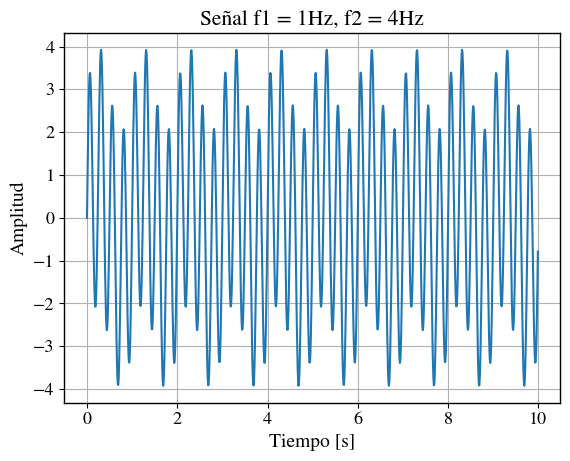

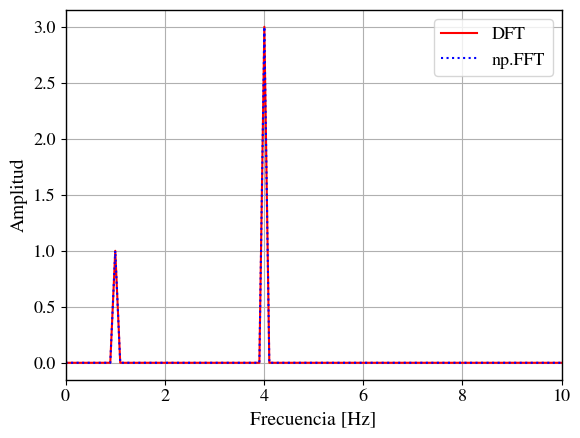

Manual, N=100
Manual, N=1000
Manual, N=10000
Numpy, N=100
Numpy, N=1000
Numpy, N=10000
Demoras manuales:[np.float64(0.014875332514444986), np.float64(1.656838099161784), np.float64(170.60436749458313)]
Demoras numpy:[np.float64(0.0010414600372314453), np.float64(0.0), np.float64(0.0)]


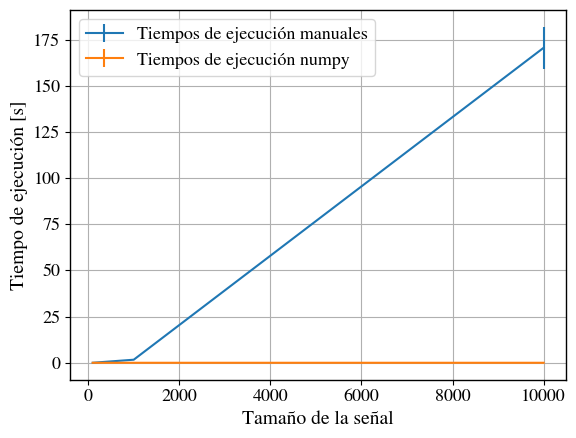

C:\Users\guacoluco\AppData\Local\Temp\ipykernel_3416\1066161503.py:146: RuntimeWarning: divide by zero encountered in log10
  log_t_fft = np.log10(res_numpy)


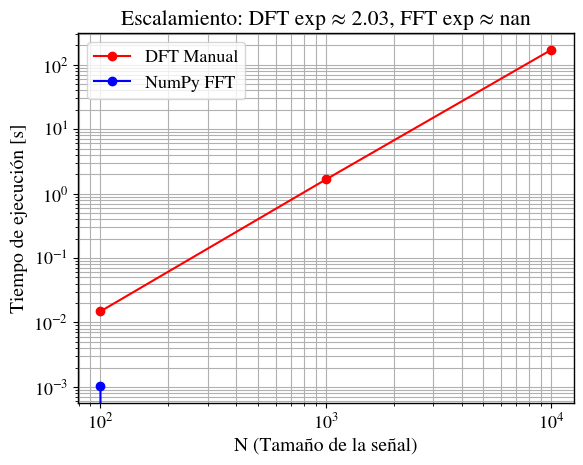

Exponente experimental DFT: 2.03
Exponente experimental FFT: nan
The root found is: 647.2775124394004


In [166]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.optimize import fsolve


#(a)
def Signal_1(t):
    return np.sin(2*np.pi*1*t) + 3*np.sin(2*np.pi*4*t)
#(b)
def DiscreteFourierTransform(Signal):
    """
    Signal: numpy array with the time-dependant signal to transform.
    """

    N = len(Signal)
    result=[]
    for k in range(N):    #iteramos sobre las frecuencias permitidas (acotadas por el teo. de Nyquist creo?)
        X_k=0
        for n in range(N):# iteramos sobre nuestro espacio muestral de la señal
            val = Signal[n] * np.exp(-1j*2*np.pi*n*k/N)     #n-esimo termino de la sumatoria
            X_k += val                                      #vamos sumando
        result.append(X_k)                                  #Añadimos valor de DFT al resultado
    return np.array(result)


#Testeo del código:
# (c) y (d)

#Creemos la señal:
largo_señal = 10 #[s]
sampling_freq = 102.4 #Hz  usanmos potencia de 2
N = int(largo_señal*sampling_freq)
dt = 1/sampling_freq #[s]

time_vector = np.linspace(0,largo_señal, N, endpoint=False) #time array
Señal = Signal_1(time_vector)   #Señal "original"
# hacemos el vector de frecuencias para que el gráfico nos aparezca con las frecuencias correctamente escaladas
freq_vector_manual = np.linspace(0, sampling_freq/2, N//2)   #Cortamos en freq/2 por teorema de Nyquist y largo a la mitad por simetría

plt.plot(time_vector, Señal)
plt.title("Señal f1 = 1Hz, f2 = 4Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

DFT_señal = DiscreteFourierTransform(Señal)
plt.plot(freq_vector_manual, 2/N*np.abs(DFT_señal)[:N//2], label = "DFT", color ="r")

# Ahora con numpy
FFT_señal = np.fft.fft(Señal)
plt.plot(freq_vector_manual, 2/N*np.abs(FFT_señal)[:N//2] , label = "np.FFT", linestyle = ":", color = "blue")
plt.xlim(0,10)
plt.grid()
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud")
plt.legend()
plt.show()



#(e)
largo_señal = 10 #[s]
TamañosDeSeñal = [100, 1000, 10000]

# primero con algoritmo hecho a mano
resultados_algoritmo_manual = {}

for N in TamañosDeSeñal:
    print(f"Manual, N={N}")
    # definimos parámetros de la señal
    sampling_freq = N / largo_señal #[Hz]
    dt = 1/sampling_freq #[s]
    time_vector = np.linspace(0,largo_señal, N, endpoint=False) #time array
    Señal = Signal_1(time_vector)   #Señal "original"

    tiempos_de_ejecucion=[]
    for repeticion in range(15): #vamos a medir 15 veces cada tiempo de ejecución para obtener una medición más estable
        t_0 = time.time()
        DFT_señal = DiscreteFourierTransform(Señal)
        process_time = time.time() - t_0
        tiempos_de_ejecucion.append(process_time)
    resultados_algoritmo_manual[N] =(np.mean(tiempos_de_ejecucion), np.std(tiempos_de_ejecucion))


# ahora con np.fft.fft
resultados_algoritmo_numpy = {}

for N in TamañosDeSeñal:
    print(f"Numpy, N={N}")
    # definimos parámetros de la señal
    sampling_freq = N / largo_señal #[Hz]
    dt = 1/sampling_freq #[s]
    time_vector = np.linspace(0,largo_señal, N, endpoint=False) #time array
    Señal = Signal_1(time_vector)   #Señal "original"

    tiempos_de_ejecucion=[]
    for repeticion in range(15): #vamos a medir 5 veces cada tiempo de ejecución para obtener una medición más estable
        t_0 = time.time()
        DFT_señal = np.fft.fft(Señal)
        process_time = time.time() - t_0
        tiempos_de_ejecucion.append(process_time)
    resultados_algoritmo_numpy[N] = (np.mean(tiempos_de_ejecucion) , np.std(tiempos_de_ejecucion))





# (f) graficar resultados:
res_manuales = []
res_numpy = []

var_manuales = []
var_numpy = []
for N in TamañosDeSeñal:
    res_manuales.append(resultados_algoritmo_manual[N][0])
    res_numpy.append(resultados_algoritmo_numpy[N][0])
    var_manuales.append(resultados_algoritmo_manual[N][1])
    var_numpy.append(resultados_algoritmo_numpy[N][1])

print(f"Demoras manuales:{res_manuales}")
print(f"Demoras numpy:{res_numpy}")

plt.errorbar(TamañosDeSeñal, res_manuales, yerr=var_manuales, label="Tiempos de ejecución manuales")
plt.errorbar(TamañosDeSeñal, res_numpy, yerr=var_numpy, label="Tiempos de ejecución numpy")
plt.legend()
plt.grid(True, which="both", ls="-")
plt.xlabel("Tamaño de la señal")
plt.ylabel("Tiempo de ejecución [s]")
plt.show()


# (g) graficar escalas log-log
plt.loglog(TamañosDeSeñal[:len(res_manuales)], res_manuales, 'ro-', label="DFT Manual")
plt.loglog(TamañosDeSeñal, res_numpy, 'bo-', label="NumPy FFT")

# 2. Estimar el exponente usando un ajuste lineal sobre los logaritmos
# Ajuste para DFT Manual: log(t) = m*log(N) + b
log_N_man = np.log10(TamañosDeSeñal[:len(res_manuales)])
log_t_man = np.log10(res_manuales)
slope_man, _ = np.polyfit(log_N_man, log_t_man, 1)

# Ajuste para FFT Numpy:
log_N_fft = np.log10(TamañosDeSeñal)
log_t_fft = np.log10(res_numpy)
slope_fft, _ = np.polyfit(log_N_fft, log_t_fft, 1)



plt.title(f"Escalamiento: DFT exp ≈ {slope_man:.2f}, FFT exp ≈ {slope_fft:.2f}")
plt.xlabel("N (Tamaño de la señal)")
plt.ylabel("Tiempo de ejecución [s]")
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

print(f"Exponente experimental DFT: {slope_man:.2f}")
print(f"Exponente experimental FFT: {slope_fft:.2f}")

#Encontrar cuando time_fft * 100 = time_DFT
def f(x):
    return x - 100*np.log(x)

# Provide an initial guess (e.g., x = 1)
root = fsolve(f,600)

print(f"The root found is: {root[0]}")

## expandimos el dominio de medición para np.fft:

Numpy, N=1000000
Numpy, N=3000000
Numpy, N=6000000
Numpy, N=10000000
[1000000, 3000000, 6000000, 10000000]
[(np.float64(0.04140458106994629), np.float64(0.0052677519643558246)), (np.float64(0.1405348777770996), np.float64(0.02223379591521555)), (np.float64(0.2614312966664632), np.float64(0.03592822529024579)), (np.float64(0.42409429550170896), np.float64(0.018750033097493537))]
Exponente experimental FFT: 1.01


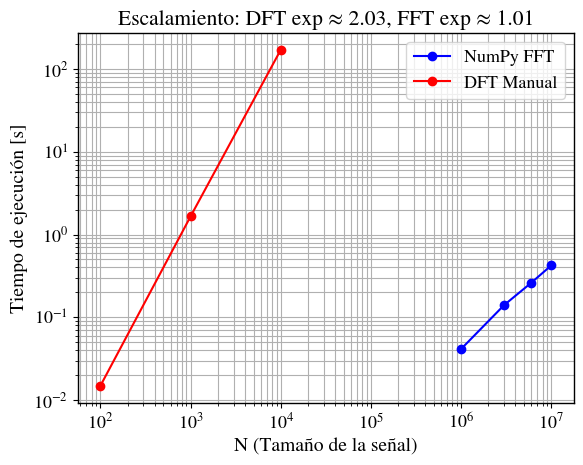

In [179]:
# Medicion para largos de señal más largos específicos para np.fft:
TamañosDeSeñal_np = [int(1e6), int(3e6), int(6e6), int(1e7)]
TamañosDeSeñal = [100, 1000, 10000]

resultados_algoritmo_numpy = {}

for N in TamañosDeSeñal_np:
    print(f"Numpy, N={N}")
    # definimos parámetros de la señal
    sampling_freq = N / largo_señal #[Hz]
    dt = 1/sampling_freq #[s]
    time_vector = np.linspace(0,largo_señal, N, endpoint=False) #time array
    Señal = Signal_1(time_vector)   #Señal "original"

    tiempos_de_ejecucion=[]
    for repeticion in range(15): #vamos a medir 5 veces cada tiempo de ejecución para obtener una medición más estable
        t_0 = time.time()
        DFT_señal = np.fft.fft(Señal)
        process_time = time.time() - t_0
        tiempos_de_ejecucion.append(process_time)
    resultados_algoritmo_numpy[N] = (np.mean(tiempos_de_ejecucion) , np.std(tiempos_de_ejecucion))

print(list(resultados_algoritmo_numpy.keys()))
print(list(resultados_algoritmo_numpy.values()))
res_numpy = []
for N in TamañosDeSeñal_np:
    res_numpy.append(resultados_algoritmo_numpy[N][0])

# Ajuste para FFT Numpy:
log_N_fft = np.log10(TamañosDeSeñal_np)
log_t_fft = np.log10(res_numpy)
slope_fft, _ = np.polyfit(log_N_fft, log_t_fft, 1)
print(f"Exponente experimental FFT: {slope_fft:.2f}")


plt.loglog(TamañosDeSeñal_np, res_numpy, 'bo-', label="NumPy FFT")
plt.loglog(TamañosDeSeñal[:len(res_manuales)], res_manuales, 'ro-', label="DFT Manual")
plt.title(f"Escalamiento: DFT exp ≈ {slope_man:.2f}, FFT exp ≈ {slope_fft:.2f}")
plt.xlabel("N (Tamaño de la señal)")
plt.ylabel("Tiempo de ejecución [s]")
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()




#Problema 3


## Versión con todas las fuerzas + plots

Usando: cpu
Iter 0 - Error: 3400.67724609 m  lr: 0.50000000
Iter 100 - Error: 3001.61865234 m  lr: 0.50000000
Iter 200 - Error: 2385.68774414 m  lr: 0.50000000
Iter 300 - Error: 1215.44177246 m  lr: 0.50000000
Iter 400 - Error: 953.44451904 m  lr: 0.25000000
Iter 500 - Error: 8.99636841 m  lr: 0.00390625
Iter 600 - Error: 0.35968933 m  lr: 0.00024414
Iter 700 - Error: 0.02802863 m  lr: 0.00003052
Iter 800 - Error: 0.00355474 m  lr: 0.00000024
--- Early Stopping activado en la iteración 845 ---
La pérdida no mejoró significativamente en 100 pasos.


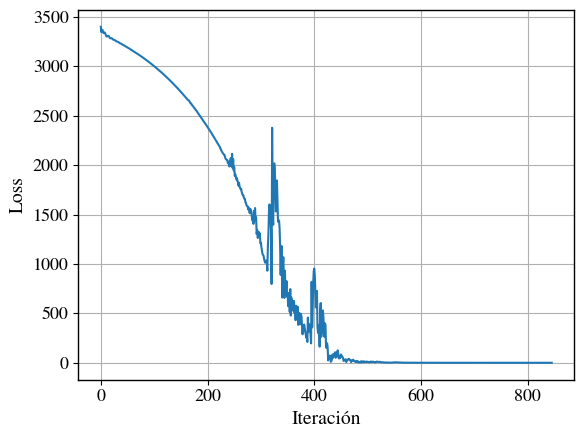

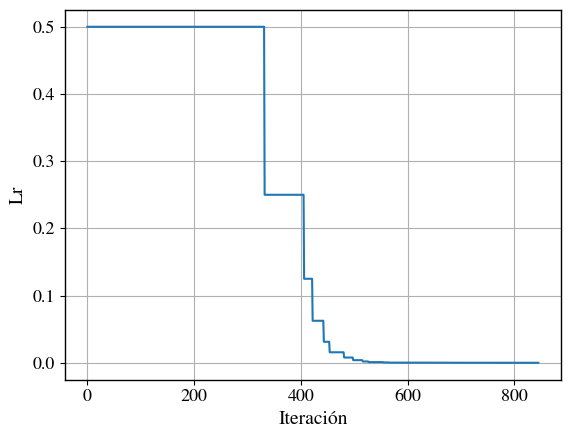


Parámetros óptimos:
v2_0: 296.11, theta: -0.54, phi: -2.44, t: 38.75

Theta: 0.54, phi: 0.70
Misil(Pos=[5000. 2000.    0.], Vel=[116.62367678  97.75876197 254.01561882])


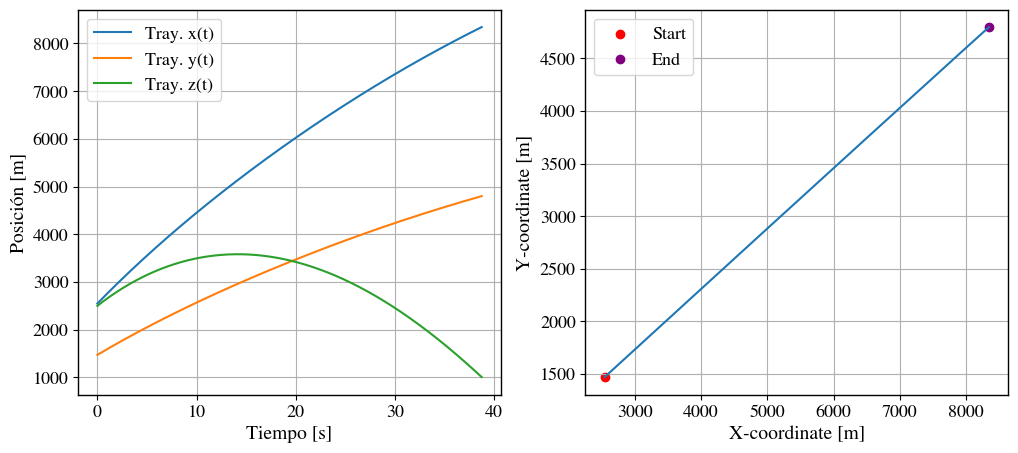

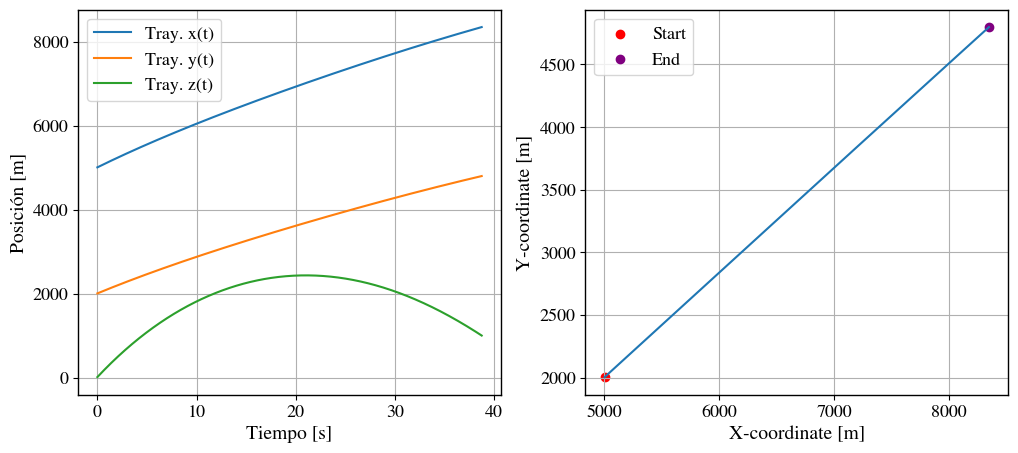

Misil 1: Misil(Pos=[8343.59635184 4798.41877846 1003.27590085], Vel=[ 103.67013655   59.12538879 -193.29214091])
Misil 2: Misil(Pos=[8345.42930825 4798.58753662 1001.3302412 ], Vel=[  66.89486559   55.64687683 -154.31695742])
Distancia entre misil 1 y 2: 2.678 -- [ 1.83295641  0.16875816 -1.94565966]


In [167]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np


# 1. Detectar si hay una GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print(f"Usando: {device}")


# Constantes físicas
rho = 1.225        # Densidad del aire (kg/m^3) al nivel del mar
Cd = 0.3          # Coeficiente de arrastre (forma de proyectil)
Area = 0.05        # Área transversal del misil (m^2)
masa = 100.0        # Masa del misil (kg)
Omega_e = 7.2921e-5 # Velocidad angular de la Tierra (rad/s)
latitud = torch.tensor(np.radians(45.0)).to(device) # Ejemplo: Latitud 45°
Latitud_np = np.radians(45.0)
dtype = torch.float32
# Vector Omega en coordenadas locales (Norte-Arriba)
# Suponiendo un sistema donde X=Este, Y=Norte, Z=Zenit (Arriba)
omega_vec = torch.tensor([0, Omega_e * torch.cos(latitud), Omega_e * torch.sin(latitud)], dtype=dtype, device=device)

def step_physics(pos, vel, dt):
    # 1. Magnitud de la velocidad
    v_norm = torch.norm(vel)

    # 2. Fuerza de Arrastre (Drag)
    # Fa = -0.5 * rho * Cd * A * |v| * v
    f_drag = -0.5 * rho * Cd * Area * v_norm * vel
    a_drag = f_drag / masa

    # 3. Fuerza de Coriolis
    # a_cor = -2 * Omega x v
    a_coriolis = -2.0 * torch.linalg.cross(omega_vec, vel)

    # 4. Gravedad
    a_grav = torch.tensor([0.0, 0.0, -9.81], dtype=dtype, device=device)

    # Aceleración total
    accel_total = a_grav + a_drag + a_coriolis

    # Actualización (Método de Euler o RK4)
    new_vel = vel + accel_total * dt
    new_pos = pos + new_vel * dt

    return new_pos, new_vel


class Misil:
    def __init__(self, x=0.0, y=0.0, z=0.0, v_0=0, theta=0, phi=0):
        # Usamos arrays de numpy para facilitar cálculos vectoriales
        self.position = np.array([x, y, z], dtype=float)
        self.velocity = np.array([v_0*np.sin(theta)*np.cos(phi), v_0*np.sin(theta)*np.sin(phi), v_0*np.cos(theta)], dtype=float)

    def get_speed(self):
        # La rapidez es la norma (magnitud) del vector velocidad
        return np.linalg.norm(self.velocity)

    def get_direction(self):
        speed = self.get_speed()
        if speed == 0:
            return np.array([0, 0, 0])
        # Un vector unitario que representa la dirección
        return self.velocity / speed

    def update(self, dt, acceleration=np.array([0, 0, 0])):
        """
        Actualiza posición y velocidad basado en un diferencial de tiempo (dt)
        y una aceleración externa opcional.
        """
        omega_vec = np.array([0, Omega_e * np.cos(Latitud_np), Omega_e * np.sin(Latitud_np)], dtype=np.float32)
        # 1. Magnitud de la velocidad
        v_norm = self.get_speed()
        vel = self.velocity
        # 2. Fuerza de Arrastre (Drag)
        # Fa = -0.5 * rho * Cd * A * |v| * v
        f_drag = -0.5 * rho * Cd * Area * v_norm * vel
        a_drag = f_drag / masa

        # 3. Fuerza de Coriolis
        # a_cor = -2 * Omega x v
        a_coriolis = -2.0 * np.cross(omega_vec, vel)

        # 4. Gravedad
        a_grav = np.array([0.0, 0.0, -9.81], dtype=np.float32)

        # Aceleración total
        accel_total = a_grav + a_drag + a_coriolis

        # v = v0 + a * dt
        self.velocity += accel_total * dt
        # x = x0 + v * dt
        self.position += self.velocity * dt
        if self.position[2] < 0:
            print(f"Misil chocó con el suelo en (x,y,z)= {self.position}")
            self.position[2] = 0

    def __repr__(self):
        return f"Misil(Pos={self.position}, Vel={self.velocity})"

def plot_trayectorias(tr_x, tr_y, tr_z, time):

    fig, ax = plt.subplots(1,2, figsize=(12,5))

    ax[0].plot(time, tr_x, label="Tray. x(t)")
    ax[0].plot(time, tr_y, label="Tray. y(t)")
    ax[0].plot(time, tr_z, label="Tray. z(t)")
    ax[0].grid()
    ax[0].set_xlabel("Tiempo [s]")
    ax[0].set_ylabel("Posición [m]")
    ax[0].legend()

    ax[1].plot(tr_x, tr_y)
    ax[1].scatter(tr_x[0], tr_y[0], label="Start", c="r")
    ax[1].scatter(tr_x[-1], tr_y[-1], label="End", c="purple")
    ax[1].grid()
    ax[1].legend()
    ax[1].set_xlabel("X-coordinate [m]")
    ax[1].set_ylabel("Y-coordinate [m]")
    plt.show()


def get_velocity_vector(v, theta, phi):
    # Conversión de esféricas a cartesianas
    th = theta
    ph = phi

    vx = v * torch.sin(th) * torch.cos(ph)
    vy = v * torch.sin(th) * torch.sin(ph)
    vz = v * torch.cos(th)
    return torch.cat([vx, vy, vz])

def normalizar_angulos(theta, phi):
    x = np.sin(theta)*np.cos(phi)
    y = np.sin(theta)*np.sin(phi)
    z = np.cos(theta)

    theta_new = np.arccos(z)
    phi_new = np.arctan2(y,x)

    x = np.sin(theta_new)*np.cos(phi_new)
    y = np.sin(theta_new)*np.sin(phi_new)
    z = np.cos(theta_new)
    return theta_new, phi_new



# 2. Inicializar params a optimizar
time_resolution = 20 #hz

v2_0 = torch.tensor([50.0], requires_grad=True, dtype=dtype, device=device)
theta2 = torch.tensor([0.5], requires_grad=True, dtype=dtype, device=device)
phi2 = torch.tensor([1.0], requires_grad=True, dtype=dtype, device=device)

# 3. declarar condiciones iniciales
# 3.1 calcular pos del Misil 1 tras 10seg:
Misil_1 = Misil(x=0, y=0, z=0, v_0=500, theta = 45*np.pi/180, phi=30*np.pi/180)     #Inicializamos el misil 1
for idx, t in enumerate(np.linspace(0,10, 10*time_resolution)):
    Misil_1.update(dt=1/time_resolution, acceleration=np.array([0, 0, -9.8]))

g = torch.tensor([0.0, 0.0, -9.8], dtype=dtype, device=device)
p1_0 = torch.tensor(Misil_1.position, dtype=dtype, device=device)
v1 = torch.tensor(Misil_1.velocity, dtype=dtype, device=device)
p2_0 = torch.tensor([5000.0, 2000.0, 0.0], dtype=dtype, device=device)

optimizer = optim.Adam([v2_0, theta2, phi2], lr=5e-1)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
# Habiendo inicializado los parámetos del Misil_1 para la optimización, terminamos de calcular su trayectoria:


# Ciclo de optimización (Backpropagation)
Loss_list=[1e4]
lr_history = []
best_params = []

patience_early_stop = 100  # ojo que tiene que ser mayor que el patience del scheduler
min_delta = 0.00005          # Mejora mínima necesaria para considerar que hay progreso (en metros
counter = 0
best_loss = min(Loss_list)

for i in range(6000):

    optimizer.zero_grad()

    # Estado inicial Misil 1 (ya pasaron 10s)
    p1 = p1_0.clone()
    v1_curr = v1.clone()

    # Estado inicial Misil 2 (lanzamiento)
    p2 = p2_0.clone()
    v2_curr = get_velocity_vector(v2_0, theta2, phi2).to(device)

    min_dist = torch.tensor(1e9, dtype=dtype, device=device)
    dt_sim = torch.tensor(1/time_resolution, dtype=dtype, device=device) # Paso de tiempo para la simulación interna

    # Simulamos 40 segundos de persecución (400 pasos)
    sim_time = 40 #seg.

    for idx in range(int(sim_time/dt_sim.item())):
        p1, v1_curr = step_physics(p1, v1_curr, dt_sim)
        p2, v2_curr = step_physics(p2, v2_curr, dt_sim)

        dist = torch.norm(p1 - p2)

        if dist < min_dist:
            min_dist = dist
            if dist < min(Loss_list):
                best_params = [v2_0.item(), theta2.item(), phi2.item(), idx*dt_sim.item()]


        if p1[2] < 0 or p2[2] < 0: break # Si alguien toca el suelo

    loss = min_dist
    Loss_list.append(loss.item())
    loss.backward()
    optimizer.step()
    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)
    scheduler.step(loss)

    #Early stopping
    if loss.item() < best_loss - min_delta:
        best_loss = loss.item()
        counter = 0
    else:
        counter += 1

    if counter >= patience_early_stop:
        print(f"--- Early Stopping activado en la iteración {i} ---")
        print(f"La pérdida no mejoró significativamente en {patience_early_stop} pasos.")
        break

    if i % 100 == 0:
        print(f"Iter {i} - Error: {loss.item():.8f} m  lr: {current_lr:.8f}")


Loss_list.pop(0)    #para sacar ese 1e4 que habíamos puesto
plt.plot(Loss_list)
plt.xlabel("Iteración")
plt.ylabel("Loss")
plt.grid()
plt.show()

plt.plot(lr_history)
plt.xlabel("Iteración")
plt.ylabel("Lr")
plt.grid()
plt.show()


print(f"\nParámetros óptimos:\nv2_0: {best_params[0]:.2f}, theta: {best_params[1]:.2f}, phi: {best_params[2]:.2f}, t: {best_params[3]:.2f}")
v0_new = best_params[0]
theta_new = best_params[1]
phi_new = best_params[2]
t_colission = best_params[3]

# suele suceder que nos encontramos con ángulos negativos, en vez de imponer constraints sobre el search, podemos pasar los ángulos negativos a sus equivalentes normales en coords. esféricas
if best_params[1]<0 or best_params[1]>np.pi/2 or best_params[2]<0 or best_params[2]>2*np.pi:
    theta_new, phi_new = normalizar_angulos(best_params[1], best_params[2])
    print(f"\nTheta: {theta_new:.2f}, phi: {phi_new:.2f}")

## Misil 2: Parámetros optimizados
Misil_2 = Misil(5000, 2000, 0, v_0=v0_new, theta=theta_new, phi=phi_new)
print(Misil_2)



t_0 = 0 #s
time_vector = np.linspace(t_0,t_colission,int(time_resolution*(t_colission-t_0)))

trayectoria_x_1=[]
trayectoria_y_1=[]
trayectoria_z_1=[]


trayectoria_x_2=[]
trayectoria_y_2=[]
trayectoria_z_2=[]

for _ in range(int(t_colission*time_resolution)):
    Misil_2.update(dt=1/time_resolution, acceleration=np.array([0, 0, -9.8]))
    Misil_1.update(dt=1/time_resolution, acceleration=np.array([0, 0, -9.8]))

    trayectoria_x_1.append(Misil_1.position[0])
    trayectoria_y_1.append(Misil_1.position[1])
    trayectoria_z_1.append(Misil_1.position[2])

    trayectoria_x_2.append(Misil_2.position[0])
    trayectoria_y_2.append(Misil_2.position[1])
    trayectoria_z_2.append(Misil_2.position[2])

#Ahora usamos el nuevo tiempo límite con el que nos aseguramos de no estár ploteando post-colisión con el piso
plot_trayectorias(trayectoria_x_1, trayectoria_y_1, trayectoria_z_1, time_vector)
plot_trayectorias(trayectoria_x_2, trayectoria_y_2, trayectoria_z_2, time_vector)
print(f"Misil 1: {Misil_1}")
print(f"Misil 2: {Misil_2}")


print(f"Distancia entre misil 1 y 2: {np.linalg.norm(Misil_2.position-Misil_1.position):.3f} -- {Misil_2.position-Misil_1.position}")


## Animaciones y GIF

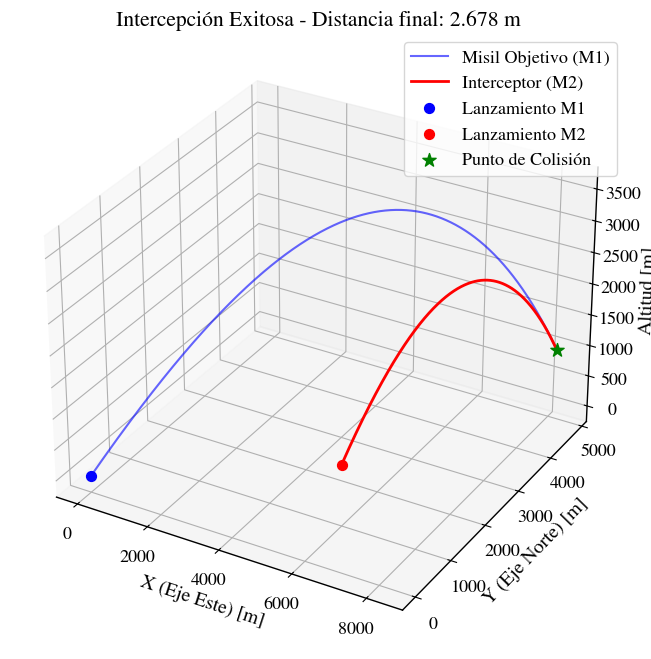

¡GIF guardado exitosamente como 'intercepcion_misiles.gif'!


In [180]:
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 256.0
# --- 1. RE-SIMULACIÓN TOTAL PARA VISUALIZACIÓN ---
# Necesitamos capturar el Misil 1 desde el segundo 0
m1_visual = Misil(x=0, y=0, z=0, v_0=500, theta=45*np.pi/180, phi=30*np.pi/180)
m2_visual = Misil(5000, 2000, 0, v_0=v0_new, theta=theta_new, phi=phi_new)

dt_v = 1/time_resolution
t_total_sim = 10 + t_colission # 10s de ventaja + tiempo de vuelo del interceptor
n_steps = int(t_total_sim * time_resolution)

hist1 = []
hist2 = []

for s in range(n_steps):
    t_actual = s * dt_v

    # El Misil 1 siempre se mueve
    m1_visual.update(dt_v)
    hist1.append(m1_visual.position.copy())

    # El Misil 2 solo se mueve después de los 10 segundos
    if t_actual >= 10:
        m2_visual.update(dt_v)
        hist2.append(m2_visual.position.copy())
    else:
        # Antes de los 10s, el Misil 2 está quieto en su base
        hist2.append(np.array([5000.0, 2000.0, 0.0]))

hist1 = np.array(hist1)
hist2 = np.array(hist2)

# --- 2. PLOTEO 3D ESTÁTICO (Punto e) ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Trayectorias
ax.plot(hist1[:,0], hist1[:,1], hist1[:,2], label='Misil Objetivo (M1)', color='blue', alpha=0.6)
ax.plot(hist2[int(10*time_resolution):,0], hist2[int(10*time_resolution):,1], hist2[int(10*time_resolution):,2],
        label='Interceptor (M2)', color='red', linewidth=2)

# Puntos clave
ax.scatter(0, 0, 0, color='blue', s=50, label='Lanzamiento M1')
ax.scatter(5000, 2000, 0, color='red', s=50, label='Lanzamiento M2')
ax.scatter(hist1[-1,0], hist1[-1,1], hist1[-1,2], color='green', s=100, marker='*', label='Punto de Colisión')

ax.set_xlabel('X (Eje Este) [m]')
ax.set_ylabel('Y (Eje Norte) [m]')
ax.set_zlabel('Altitud [m]')
ax.set_title(f'Intercepción Exitosa - Distancia final: {np.linalg.norm(hist1[-1]-hist2[-1]):.3f} m')
ax.legend()
plt.show()

# --- 3. ANIMACIÓN (Punto f) ---
fig_anim = plt.figure(figsize=(10, 7))
ax_an = fig_anim.add_subplot(111, projection='3d')

# Configurar límites de la caja de animación
ax_an.set_xlim(0, max(hist1[:,0].max(), hist2[:,0].max()))
ax_an.set_ylim(0, max(hist1[:,1].max(), hist2[:,1].max()))
ax_an.set_zlim(0, max(hist1[:,2].max(), hist2[:,2].max()))

line1, = ax_an.plot([], [], [], 'b-', alpha=0.3)
line2, = ax_an.plot([], [], [], 'r-', alpha=0.3)
point1, = ax_an.plot([], [], [], 'bo', label='Objetivo')
point2, = ax_an.plot([], [], [], 'ro', label='Interceptor')
time_text = ax_an.text2D(0.05, 0.95, '', transform=ax_an.transAxes)

def init():
    line1.set_data([], [])
    line1.set_3d_properties([])
    line2.set_data([], [])
    line2.set_3d_properties([])
    point1.set_data([], [])
    point1.set_3d_properties([])
    point2.set_data([], [])
    point2.set_3d_properties([])
    time_text.set_text('')
    return line1, line2, point1, point2, time_text

def animate(i):
    # Saltamos algunos frames para que la animación no sea eterna (opcional)
    idx = i

    # Actualizar estelas
    line1.set_data(hist1[:idx, 0], hist1[:idx, 1])
    line1.set_3d_properties(hist1[:idx, 2])
    line2.set_data(hist2[:idx, 0], hist2[:idx, 1])
    line2.set_3d_properties(hist2[:idx, 2])

    # Actualizar cabezas de los misiles
    point1.set_data([hist1[idx, 0]], [hist1[idx, 1]])
    point1.set_3d_properties([hist1[idx, 2]])
    point2.set_data([hist2[idx, 0]], [hist2[idx, 1]])
    point2.set_3d_properties([hist2[idx, 2]])

    time_text.set_text(f'Tiempo: {idx/time_resolution:.1f} s')
    return line1, line2, point1, point2, time_text

# Crear animación
ani = animation.FuncAnimation(fig_anim, animate, frames=len(hist1),
                              init_func=init, blit=True, interval=50)

plt.legend()

# Display in Jupyter
plt.close() # Prevents extra static plot from appearing
HTML(ani.to_jshtml()) # Generates interactive widget
# Para guardar la animación (necesitas ffmpeg instalado):
# ani.save('intercepcion_misiles.mp4', fps=30, extra_args=['-vcodec', 'libx264'])
from matplotlib.animation import PillowWriter

# Suponiendo que tu objeto de animación se llama 'ani' o 'anim'
# Definimos el "writer" (escritor) y los FPS (cuadros por segundo)
writer = PillowWriter(fps=30)

# Guardamos el archivo
# ani.save("C:/Users/guacoluco/OneDrive/Escritorio/USM/FIS/fisica computacional/Tareas/Tarea 1/intercepcion_misiles.gif", writer=writer)

print("¡GIF guardado exitosamente como 'intercepcion_misiles.gif'!")